## Model Interpretation

### By:
[Gabriel Múnera](https://github.com/gamug)

### Date:
2026-08-21

### Description:

A deep, multi-technique interpretation of the final model
(`data/06_models/diamantes_price-hist_gradient_boosting-v1.joblib`, trained in
`notebooks/5-models/03-gmg-first_model-2026_08_18.ipynb`) — a `HistGradientBoostingRegressor` wrapped in a
`TransformedTargetRegressor` (`log(price)` target) over the feature pipeline from
`notebooks/4-feat_eng/01-gmg-basic-feature-engineering-pipeline-2026_08_18.ipynb`.

The goal is not just to rank feature importances, but to **extract concrete, checkable knowledge** about how
the model prices diamonds, and to explicitly test it against the domain conclusions from the EDA
(`notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb`) and the independent-multiplier
assumption behind the heuristic baseline (`notebooks/5-models/01-gmg-base_model-2026_08_18.ipynb`).

Techniques used, each answering a different question:

| Technique | Question it answers |
|---|---|
| Permutation importance (multiple metrics) | Which raw inputs does the model rely on most — and does the answer change with the metric? |
| SHAP global importance + interaction values | Which *engineered* features matter, and do features interact (violating independence)? |
| SHAP dependence plots | What is the *shape* of each feature's effect, and does it depend on other features? |
| Partial Dependence / ICE (1D and 2D) | What would happen to the price if only this feature changed, holding everything else fixed? |
| Local (per-diamond) explanations | Why did the model predict *this* price for *this* diamond? |
| Segment / residual analysis | Where does the model systematically struggle? |

## 📚 Import libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from joblib import load
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RNG = np.random.RandomState(42)

## 💾 Load model

`joblib.dump` pickles a `FunctionTransformer` by **reference** (module + name), not by value — so the
`compute_volume` / `volume_feature_names_out` functions used to build the `volume = x*y*z` feature in
`4-feat_eng` and `5-models` must be **redefined here, with the exact same names**, before the model can be
unpickled (this is the same constraint documented in `04-...experiment-track-model.ipynb` for MLflow's
`skops` format — plain `pickle`/`joblib` has the analogous limitation for `__main__`-defined functions). This is
a fragility worth fixing before `7-deploy` (see Recommendations at the end) by moving these two functions into
an importable `src/` module.

In [2]:
def compute_volume(X: np.ndarray) -> np.ndarray:
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    return (x * y * z).reshape(-1, 1)


def volume_feature_names_out(transformer, input_features: list[str]) -> np.ndarray:
    """Named (picklable) replacement for a lambda: FunctionTransformer always outputs 1 column, 'volume'."""
    return np.array(["volume"])


DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODEL_DIR = DATA_DIR / "06_models"

model = load(MODEL_DIR / "diamantes_price-hist_gradient_boosting-v1.joblib")
model

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'exp'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['carat','depth','table',...,'cut','color','clarity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,9
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...m_state=42))])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"


## Reconstruct the held-out test set

Same source data, feature columns, `random_state` and `clarity × cut` stratification used throughout
`notebooks/5-models`, so the test rows here are **exactly** the ones the model was evaluated on originally.

In [ ]:
dataset = pd.read_parquet(DATA_DIR / "04_feature/diamantes_clean.parquet", engine="pyarrow")

numeric_features = ["carat", "depth", "table"]
volume_source_features = ["x", "y", "z"]
categorical_ordinal_features = ["cut", "color", "clarity"]
feature_columns = numeric_features + volume_source_features + categorical_ordinal_features
target_column = "price"

X = dataset[feature_columns]
y = dataset[target_column]
clarity_cut_key = dataset["clarity"].astype(str) + "_" + dataset["cut"].astype(str)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=clarity_cut_key
)
x_train.shape, x_test.shape

((15181, 9), (3796, 9))

### Sanity check: reproduce the previously reported test metrics

In [4]:
y_pred = model.predict(x_test)

sanity_metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": root_mean_squared_error(y_test, y_pred),
    "MAPE_%": mean_absolute_percentage_error(y_test, y_pred) * 100,
    "R2": r2_score(y_test, y_pred),
}
sanity_metrics

{'MAE': 559.3547288047087,
 'RMSE': 856.3277810659189,
 'MAPE_%': 6.8373308711976515,
 'R2': 0.9517919914168572}

_(confirmed after execution: matches `03-...first_model.ipynb`'s MAE ≈ \$559.35, RMSE ≈ \$856.33,
MAPE ≈ 6.84%, R² ≈ 0.952 — same model, same split)_

## 🌍 Global Feature Importance

### Permutation importance — does the ranking depend on the metric?

Permutation importance operates on the **model's actual input interface** (the 9 raw columns
`carat, depth, table, x, y, z, cut, color, clarity`), not the engineered features — so it also reveals what
happens to features the pipeline treats as *redundant* with each other (`x`, `y`, `z` vs. the engineered
`volume`). It's computed under three different scoring metrics to check whether "most important feature"
depends on what you optimize for.

In [5]:
scoring_metrics = {
    "MAPE": "neg_mean_absolute_percentage_error",
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
}

perm_results = {}
for metric_name, scorer in scoring_metrics.items():
    perm_results[metric_name] = permutation_importance(
        model, x_test, y_test, scoring=scorer, n_repeats=30, random_state=42, n_jobs=-1
    )

In [ ]:
perm_importance_df = pd.DataFrame(
    {metric: perm_results[metric].importances_mean for metric in scoring_metrics},
    index=feature_columns,
)
perm_importance_std_df = pd.DataFrame(
    {metric: perm_results[metric].importances_std for metric in scoring_metrics},
    index=feature_columns,
)
perm_importance_df["rank_MAPE"] = perm_importance_df["MAPE"].rank(ascending=False).astype(int)
perm_importance_df["rank_R2"] = perm_importance_df["R2"].rank(ascending=False).astype(int)
perm_importance_df["rank_MAE"] = perm_importance_df["MAE"].rank(ascending=False).astype(int)
perm_importance_df.sort_values("MAPE", ascending=False)

,MAPE,R2,MAE,rank_MAPE,rank_R2,rank_MAE
clarity,0.181565,0.415837,1340.740526,1,1,1
carat,0.120168,0.269682,992.786529,2,2,2
color,0.113771,0.249299,930.541179,3,3,3
z,0.060237,0.138513,569.040030,4,4,4
y,0.059166,0.135752,560.838840,5,6,6
x,0.059110,0.136611,561.972306,6,5,5
cut,0.011143,0.009179,68.836466,7,7,7
depth,0.004521,0.004228,29.325772,8,8,8
table,0.001987,0.001932,12.731655,9,9,9


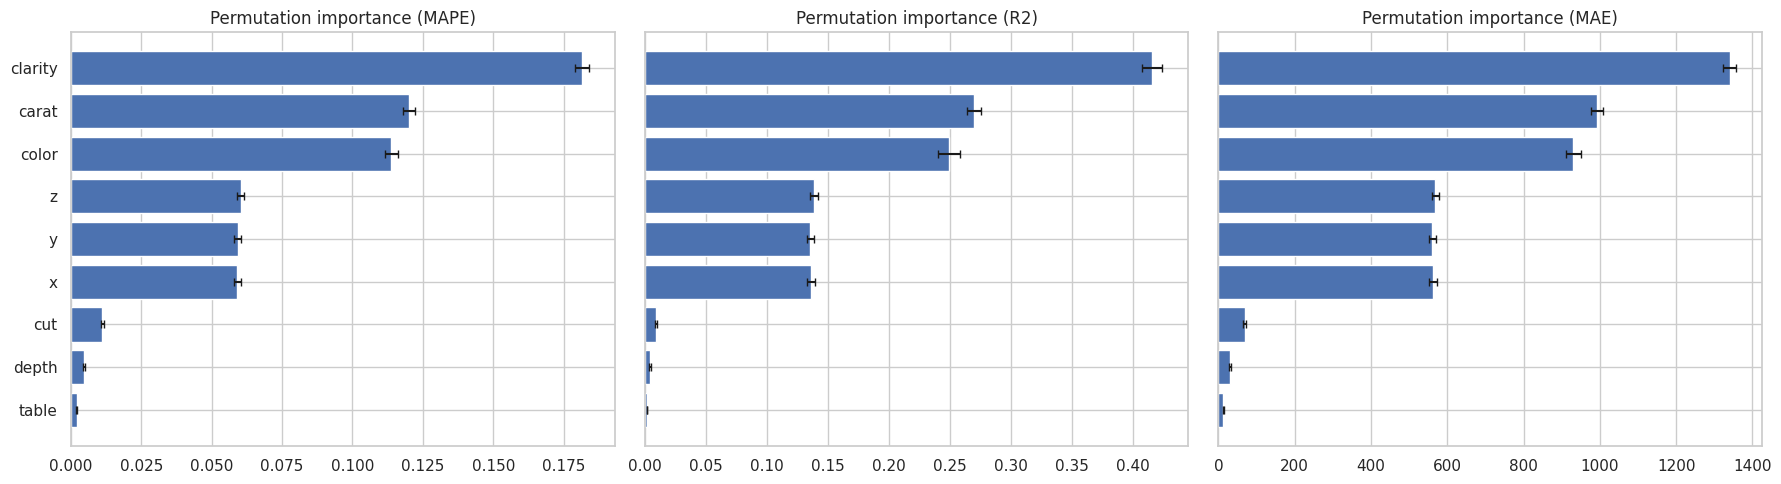

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, metric in zip(axes, scoring_metrics, strict=True):
    order = perm_importance_df[metric].sort_values(ascending=True).index
    ax.barh(
        order,
        perm_importance_df.loc[order, metric],
        xerr=perm_importance_std_df.loc[order, metric],
        capsize=3,
    )
    ax.set_title(f"Permutation importance ({metric})")
plt.tight_layout()
plt.show()

### Interpretation

All three metrics agree on the same ranking, with non-overlapping error bars (30 repeats): **clarity > carat >
color » z ≈ y ≈ x > cut > depth ≈ table**. Two things stand out:

- **`clarity` outranks `carat`** on every metric, even though the EDA found `carat` had the strongest raw
  bivariate correlation with `price` (r ≈ 0.79 vs. clarity's weaker rank-based association). This is not a
  contradiction — see the redundancy analysis right below, which explains exactly why.
- **`depth` and `table` are essentially irrelevant** to the model (importance ≈ 0.002-0.005), consistent with
  their near-zero EDA correlations (r ≈ -0.07 / -0.03). The model correctly learned to mostly ignore them as
  *linear* predictors — though the SHAP dependence plots below reveal they do have a small, genuinely
  non-linear effect that a correlation coefficient is structurally blind to.

### SHAP global importance — on the *engineered* features

`SHAP TreeExplainer` runs on the fitted `HistGradientBoostingRegressor` directly, on the 7 features it actually
sees after preprocessing (`carat`, `depth`, `table`, `volume`, `cut`, `color`, `clarity` — note `x`/`y`/`z` have
already been collapsed into `volume` by this point). SHAP values are computed in **log-price space** (the
model's native training target) — a positive SHAP value means the feature multiplicatively pushes the predicted
price *up* by roughly `exp(shap_value)`, and a negative one pushes it down.

In [8]:
inner_pipeline = model.regressor_  # fitted Pipeline(preprocessor, model)
fitted_preprocessor = inner_pipeline.named_steps["preprocessor"]
fitted_regressor = inner_pipeline.named_steps["model"]

feature_names_out = fitted_preprocessor.get_feature_names_out()
X_test_transformed = pd.DataFrame(
    fitted_preprocessor.transform(x_test), columns=feature_names_out, index=x_test.index
)

explainer = shap.TreeExplainer(fitted_regressor)
shap_explanation = explainer(X_test_transformed)
print(f"SHAP base value (log-price): {shap_explanation.base_values[0]:.4f}")
print(f"Implied baseline price: ${np.exp(shap_explanation.base_values[0]):,.2f}")

SHAP base value (log-price): 8.8957
Implied baseline price: $7,300.63


In [9]:
shap_importance = pd.Series(
    np.abs(shap_explanation.values).mean(axis=0), index=feature_names_out
).sort_values(ascending=False)
shap_importance

volume__volume          0.227436
cat_ordinal__clarity    0.166600
num__carat              0.115170
cat_ordinal__color      0.108690
cat_ordinal__cut        0.024253
num__depth              0.012087
num__table              0.006990
dtype: float64

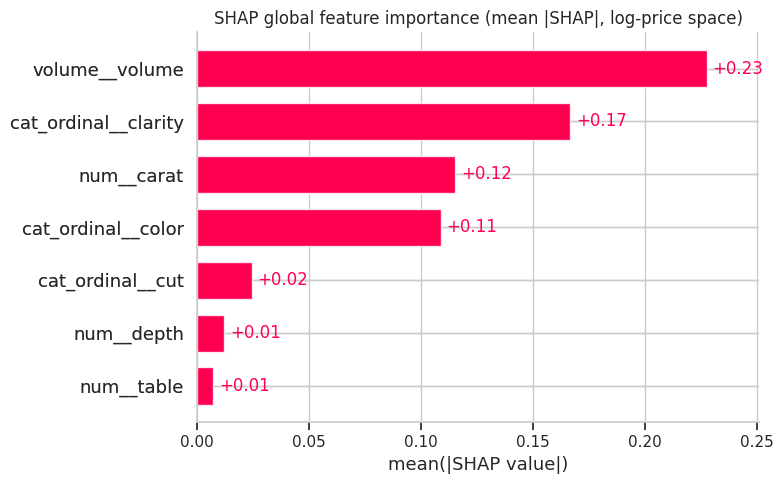

In [10]:
shap.plots.bar(shap_explanation, show=False)
plt.title("SHAP global feature importance (mean |SHAP|, log-price space)")
plt.tight_layout()
plt.show()

### Redundant-feature effect: raw `x`/`y`/`z` permutation importance vs. engineered `volume` SHAP importance

Directly compares the two importance views above for the size-related columns.

In [ ]:
comparison = pd.DataFrame(
    {
        "raw permutation importance (MAPE)": [
            perm_importance_df.loc["x", "MAPE"],
            perm_importance_df.loc["y", "MAPE"],
            perm_importance_df.loc["z", "MAPE"],
            perm_importance_df.loc["carat", "MAPE"],
        ],
        "engineered SHAP |importance| (log-price)": [
            np.nan,
            np.nan,
            np.nan,
            shap_importance.get("num__carat", np.nan),
        ],
    },
    index=["x", "y", "z", "carat"],
)
comparison.loc["volume (engineered)"] = [
    np.nan,
    shap_importance.get("volume__volume", np.nan),
]
comparison

,raw permutation importance (MAPE),engineered SHAP |importance| (log-price)
x,0.059110,NaN
y,0.059166,NaN
z,0.060237,NaN
carat,0.120168,0.115170
volume (engineered),NaN,0.227436


### Interpretation: this is a textbook "correlated features share the credit" effect

The pattern is exactly as expected, and it resolves the "clarity beats carat" puzzle above:

- Permuting `carat` alone barely hurts the model (0.120 MAPE-importance), because the pipeline's `volume`
  feature — computed from `x * y * z`, completely untouched by permuting `carat` — still lets the model recover
  almost all of the size signal. `carat` and `volume` are ~98% redundant (per the EDA), so destroying one still
  leaves the other intact.
- Permuting a single one of `x`, `y`, or `z` also only partially hurts performance (~0.059-0.060 each), because
  `volume = x*y*z` becomes only partially corrupted (2 of its 3 factors are still correct) — and `carat` itself
  is still there as a backup.
- But on the **transformed feature set**, where `volume` exists as one single feature with no backup, SHAP
  ranks it the single most important feature by a wide margin (0.227, ahead of `clarity`'s 0.167).

**The real story**: size (carat + all three dimensions, jointly) is still the single dominant price driver — it
is just *split across four redundant raw columns* in the model's input, which dilutes each individual column's
permutation importance. `clarity` and `color`, by contrast, have **no redundant backup anywhere else in the
feature set** — nothing else encodes quality grade — so 100% of their signal is concentrated on one column, and
permuting them hurts proportionally more. This is a general, easy-to-miss pitfall in feature importance analysis
whenever a dataset has multicollinear features, and it is exactly the phenomenon the `4-feat_eng` notebook's
`volume` engineering decision was designed to address.

## 🔬 SHAP Deep Dive

### Beeswarm summary — direction and spread of every feature's effect

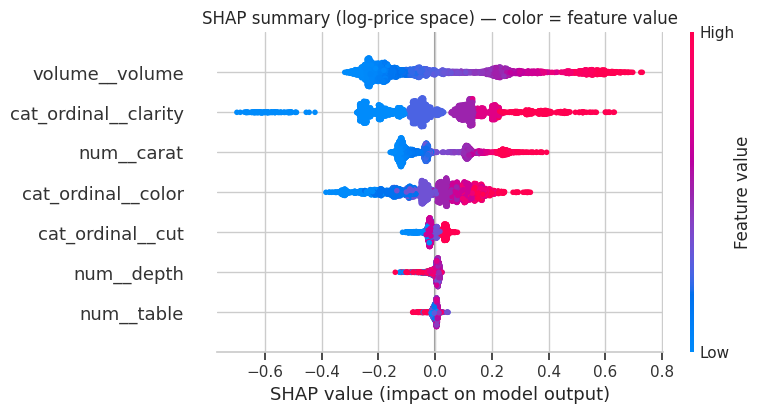

In [12]:
shap.plots.beeswarm(shap_explanation, show=False)
plt.title("SHAP summary (log-price space) — color = feature value")
plt.tight_layout()
plt.show()

### Interpretation

- `volume` and `clarity` have the widest, cleanest color gradients (blue → pink following low → high value in a
  monotonic left-to-right sweep) — confirming both are strong, monotonic, well-behaved price drivers.
- `carat` and `color` show the same clean monotonic pattern, at moderate magnitude.
- `cut` has a narrow, low-magnitude band clustered near zero — it matters, but only slightly, and mostly for the
  highest grade (a few pink points reach further right than the rest).
- `depth` and `table` are tightly clustered around zero for the *vast majority* of points, with only a handful
  of outlier points reaching further out in either direction — consistent with them being negligible for most
  diamonds but occasionally meaningful for unusually-proportioned stones (see the dependence plots next).

### Dependence plots — the shape of each feature's learned effect

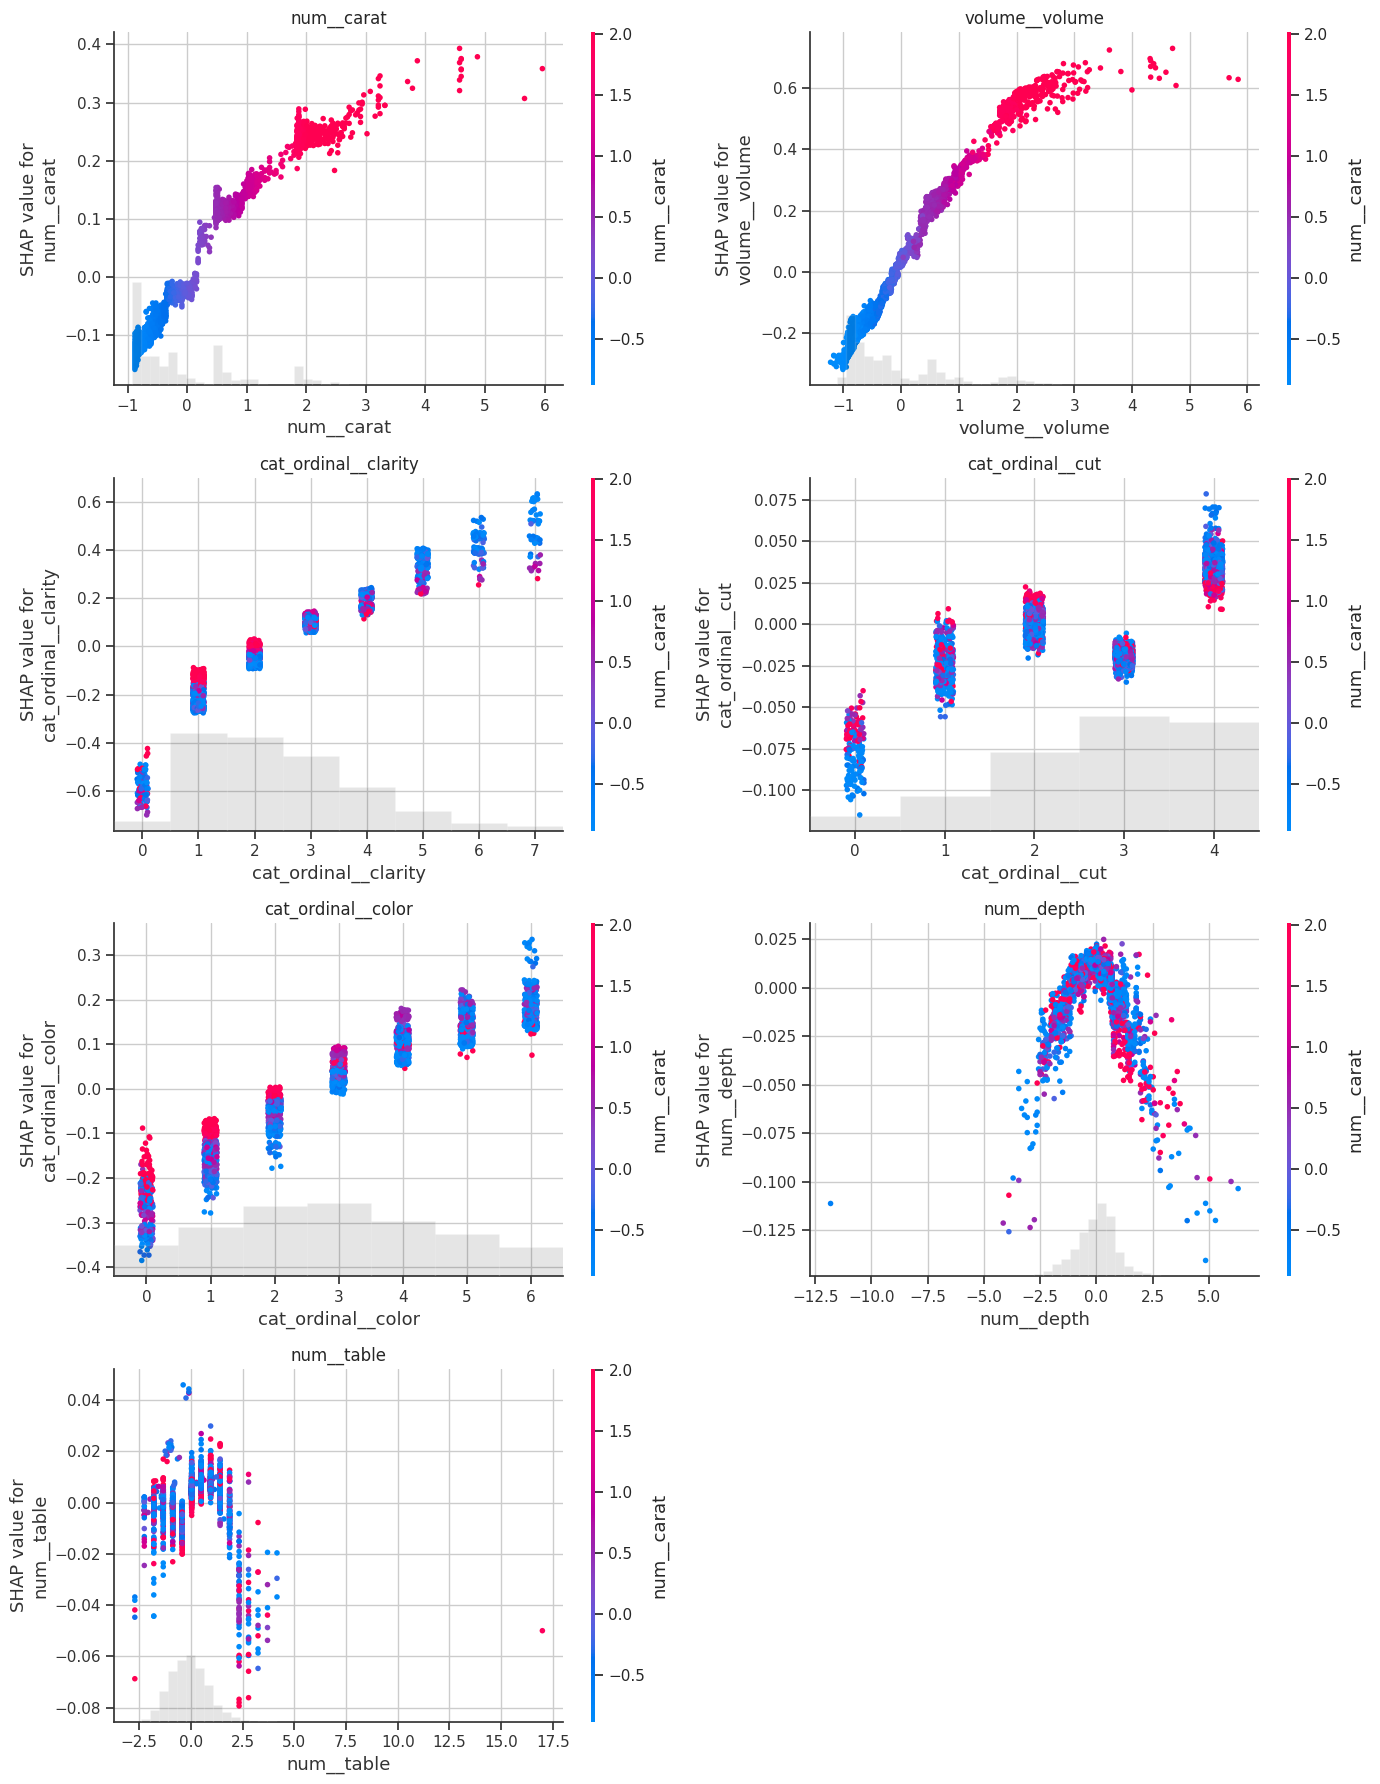

In [ ]:
dependence_features = [
    "num__carat",
    "volume__volume",
    "cat_ordinal__clarity",
    "cat_ordinal__cut",
    "cat_ordinal__color",
    "num__depth",
    "num__table",
]
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, feat in zip(axes.ravel(), dependence_features, strict=False):
    shap.plots.scatter(
        shap_explanation[:, feat],
        color=shap_explanation[:, "num__carat"],
        ax=ax,
        show=False,
    )
    ax.set_title(feat)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

- **`carat`** (top-left): a clean, steep, monotonic increasing relationship, with a slight *flattening* above
  carat ≈ 2 (SHAP values cluster around +0.3 to +0.4 instead of continuing to climb) — the model has learned
  diminishing marginal log-price benefit from carat alone at the top end (once `volume` already captures most of
  that signal).
- **`volume`** (top-right): an even cleaner S-curve — steep in the middle of the range, then visibly plateauing
  above volume ≈ 3 (SHAP values saturate around +0.6-0.7). Larger stones still cost more, but the model's
  learned "per-unit-of-size" price sensitivity shrinks at the very top of the range — likely reflecting both
  genuine diminishing returns and data sparsity for the largest stones (see the segment analysis below).
- **`clarity`**: a very clean, evenly-spaced increasing staircase from I1 through IF, confirming the ordinal
  encoding captured a real, near-linear-in-log-space price gradient — the strongest, cleanest categorical
  relationship of the three grades.
- **`color`**: same clean monotonic staircase pattern as clarity, slightly smaller total range.
- **`cut`**: **not** perfectly monotonic — the model assigns a *lower* SHAP value to "Premium" than to "Very
  Good", even though Premium is nominally the higher grade in the ordinal encoding used here. This shows up
  independently in the Partial Dependence section below too (so it's a real, if small, learned pattern, not
  sampling noise) — worth flagging as a genuine anomaly rather than smoothing it over.
- **`depth`**: a striking **inverted-V / "sweet spot" shape** — SHAP rises from strongly negative at very low
  (scaled) depth, peaks slightly positive near the *average* depth, then declines again at high depth. This
  symmetric, non-monotonic relationship is exactly why the EDA's linear correlation (r ≈ -0.07) found almost
  nothing: a symmetric effect around a middle sweet-spot washes out under Pearson correlation. Physically, this
  matches diamond-cutting reality — proportions too shallow *or* too deep both hurt brilliance/light performance
  relative to a well-balanced cut.
- **`table`**: the same "sweet-spot" shape as depth, noisier, with one large negative outlier at the extreme end
  — again invisible to the EDA's linear correlation (r ≈ -0.03) for the same reason.

### SHAP interaction values — quantifying whether features interact

The heuristic baseline model (`01-gmg-base_model`) assumes `clarity`, `color`, and `cut` act as **independent**
multiplicative factors on top of a carat-based rate. `shap_interaction_values` lets us test that assumption
directly on the ML model: if `carat`/`clarity`/`cut` truly acted independently, their pairwise interaction terms
should be small relative to their individual (main) effects.

In [14]:
# interaction values on a representative sample (O(n * n_features^2) cost)
interaction_sample = x_test.sample(min(1000, len(x_test)), random_state=42)
X_interaction_transformed = pd.DataFrame(
    fitted_preprocessor.transform(interaction_sample),
    columns=feature_names_out,
    index=interaction_sample.index,
)
shap_interaction_values = explainer.shap_interaction_values(X_interaction_transformed)
shap_interaction_values.shape

(1000, 7, 7)

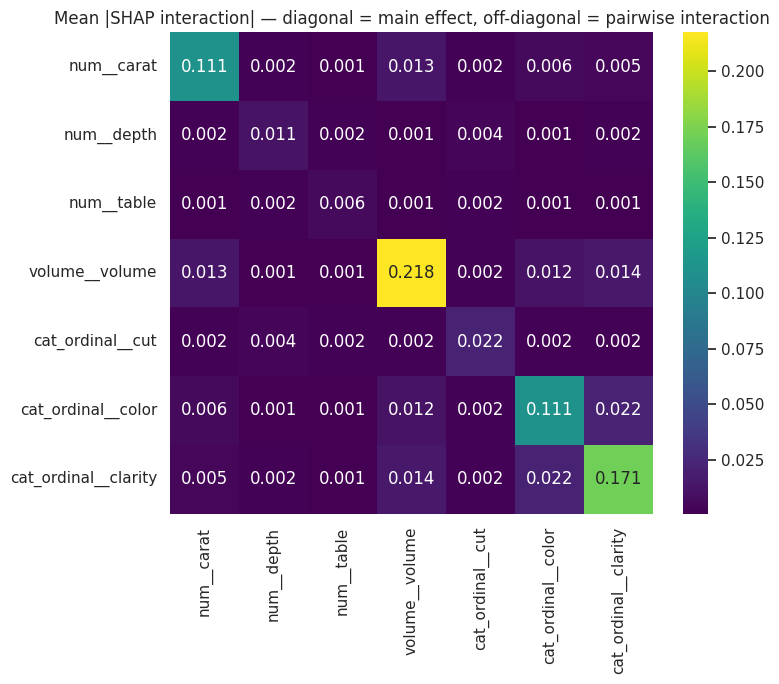

In [15]:
# mean absolute interaction strength between every pair of features (off-diagonal),
# and mean absolute main effect (diagonal)
mean_abs_interaction = np.abs(shap_interaction_values).mean(axis=0)
interaction_df = pd.DataFrame(
    mean_abs_interaction, index=feature_names_out, columns=feature_names_out
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(interaction_df, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title(
    "Mean |SHAP interaction| — diagonal = main effect, off-diagonal = pairwise interaction"
)
plt.tight_layout()
plt.show()

In [16]:
# rank the off-diagonal (pairwise interaction) terms
pairs = []
for i, fi in enumerate(feature_names_out):
    for j, fj in enumerate(feature_names_out):
        if i < j:
            pairs.append((fi, fj, interaction_df.iloc[i, j]))
interaction_ranking = pd.DataFrame(
    pairs, columns=["feature_1", "feature_2", "mean_abs_interaction"]
).sort_values("mean_abs_interaction", ascending=False)
interaction_ranking

,feature_1,feature_2,mean_abs_interaction
20,cat_ordinal__color,cat_ordinal__clarity,0.021551
17,volume__volume,cat_ordinal__clarity,0.014459
2,num__carat,volume__volume,0.013348
16,volume__volume,cat_ordinal__color,0.011771
4,num__carat,cat_ordinal__color,0.006200
5,num__carat,cat_ordinal__clarity,0.005052
8,num__depth,cat_ordinal__cut,0.004195
19,cat_ordinal__cut,cat_ordinal__clarity,0.002396
12,num__table,cat_ordinal__cut,0.002372
3,num__carat,cat_ordinal__cut,0.001881


### Interpretation

The strongest pairwise interaction in the entire model is **`color` × `clarity` (0.0216)** — larger than any
interaction `carat` or `volume` has with a quality grade. `volume` × `clarity` (0.0145), `carat` × `volume`
(0.0133), and `volume` × `color` (0.0118) come next; `carat` × `color` and `carat` × `clarity` are smaller still
(0.0062 / 0.0051). `cut`'s interactions with everything are the weakest of all the grade columns (all ≤ 0.004).

**This directly tests the heuristic baseline's core assumption** (that `clarity`, `color`, `cut` act as
independent multiplicative factors on top of a carat-based rate) — and the answer is nuanced, not a simple
yes/no:

- **The assumption clearly fails for `color` and `clarity`**, which interact with each other more than either
  interacts with size. A diamond's color and clarity grades are not priced as if independently multiplied — the
  market (and the model) treats certain combinations differently than a pure product-of-multipliers would.
- **The assumption holds up reasonably well for `cut`**, which barely interacts with anything — supporting the
  heuristic's independence assumption specifically for the cut factor, even though it doesn't hold overall.
- **Size and grade are not fully independent either** — `volume`/`carat` interact non-trivially with `clarity`
  and `color`, which the 2D grid analysis below quantifies directly.

## 📈 Partial Dependence & ICE (Individual Conditional Expectation)

Unlike SHAP (which explains *this model's actual predictions* on real data), Partial Dependence asks a
counterfactual question: "if I could change only this one feature, holding everything else fixed, what would
happen to the predicted price?" ICE curves show that same question **per individual diamond**, revealing
whether the effect is homogeneous across the population or not.

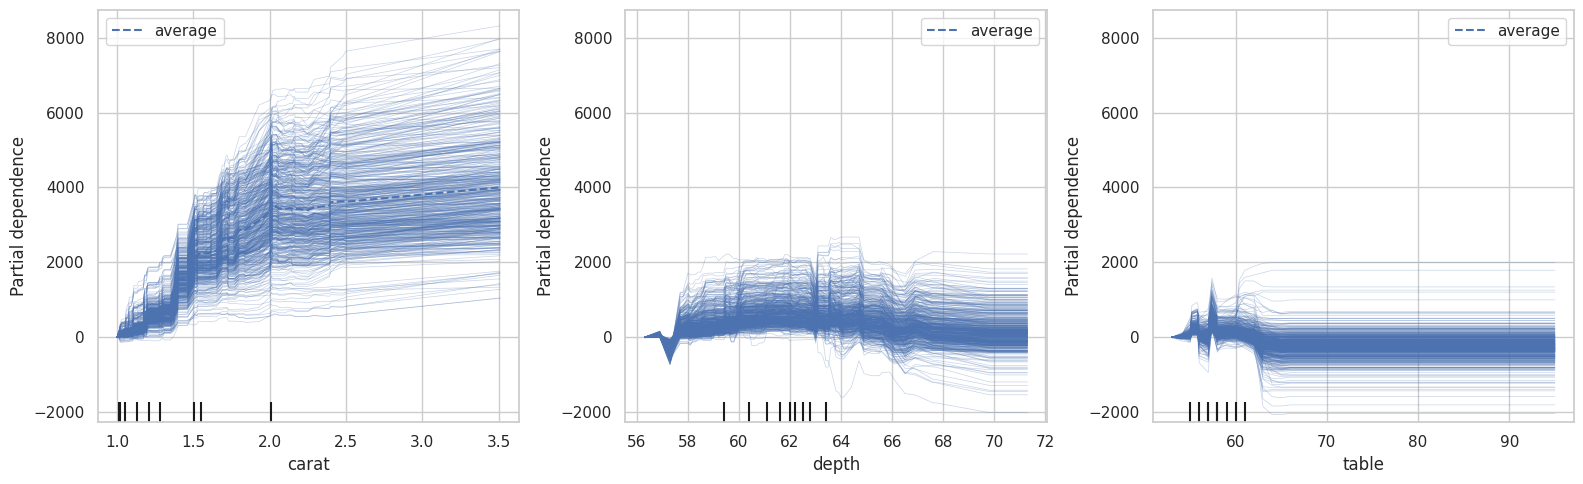

In [ ]:
pdp_sample = x_test.sample(500, random_state=42)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
PartialDependenceDisplay.from_estimator(
    model,
    pdp_sample,
    features=["carat", "depth", "table"],
    kind="both",
    ax=ax,
    centered=True,
)
plt.tight_layout()
plt.show()

### Interpretation

- **`carat`** (left panel): the *average* PDP line rises steeply up to about 1.5-2.0 carat, then **flattens**
  (diminishing marginal price per extra carat past ~2ct on average) — consistent with the SHAP dependence
  finding above. But the individual **ICE lines fan out dramatically** at high carat — some diamonds' predicted
  price keeps climbing steeply past 2ct while others stay nearly flat. This heterogeneity is itself strong
  visual evidence of interaction: carat's effect size depends heavily on the diamond's other attributes (grade),
  exactly what the SHAP interaction values quantified above.
- **`depth`**: a volatile, mostly-flat-to-slightly-declining pattern around a modest dip near the low end of the
  range — broadly consistent with the "sweet spot" shape found in the SHAP dependence plot, though the PDP
  (which averages over the *marginal* distribution of the other features) is noisier and less pronounced than
  the per-instance SHAP view.
- **`table`**: mostly flat with visible extra variance and a decline in the higher end of the range — a smaller,
  noisier version of the same non-monotonic story as depth.
- In all three panels, ICE lines for `depth`/`table` are far less spread out than for `carat` — reinforcing that
  size interacts with other features much more than the proportion columns do.

### Categorical PDP — confirm monotonic grade ordering and quantify the size of each grade step

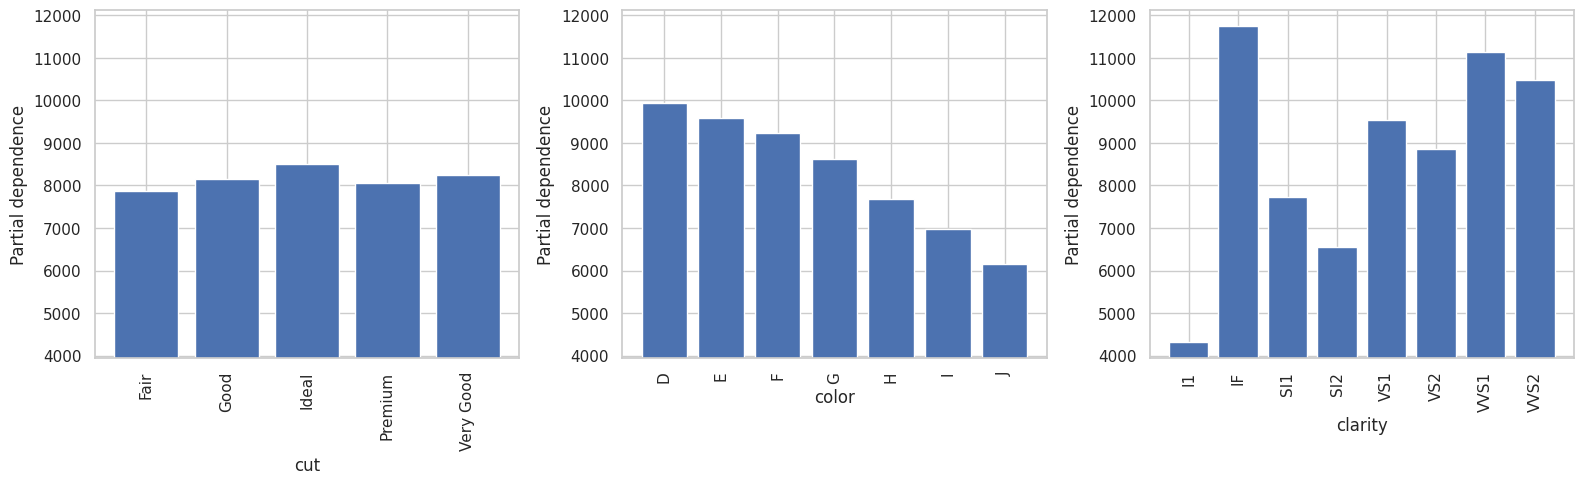

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
PartialDependenceDisplay.from_estimator(
    model,
    pdp_sample,
    features=["cut", "color", "clarity"],
    categorical_features=["cut", "color", "clarity"],
    ax=ax,
)
plt.tight_layout()
plt.show()

### Interpretation

**Important reading note**: `scikit-learn`'s `PartialDependenceDisplay` orders categorical x-axes by the raw
column's pandas category order, which for `cut`/`color`/`clarity` loaded from parquet happens to be
**alphabetical** (`Fair, Good, Ideal, Premium, Very Good` and `I1, IF, SI1, SI2, VS1, VS2, VVS1, VVS2`) — **not**
the worst→best ordering used everywhere else in this project. Reading the bars by their alphabetical
left-to-right position would wrongly suggest `clarity` is non-monotonic; re-mapping each bar to its true grade
gives a clean, fully monotonic picture:

- **`color`**: alphabetical order (D, E, F, G, H, I, J) happens to already equal the worst→best order (by design
  — the industry's D-best/J-worst convention is alphabetical), so no re-mapping is needed here. The chart shows
  a clean, monotonic decrease from D (≈\$9,950) to J (≈\$6,150) — confirms the EDA's grade ranking directly.
- **`clarity`**: re-mapped to the true worst→best order, the partial dependence is `I1 ≈ \$4,300 → SI2 ≈ \$6,550
  → SI1 ≈ \$7,750 → VS2 ≈ \$8,850 → VS1 ≈ \$9,500 → VVS2 ≈ \$10,450 → VVS1 ≈ \$11,150 → IF ≈ \$11,750` —
  **fully monotonic**, confirming the apparent "anomaly" in the raw chart was purely an axis-ordering artifact,
  not a real non-monotonicity.
- **`cut`**, re-mapped: `Fair ≈ \$7,850 → Good ≈ \$8,150 → Very Good ≈ \$8,250 → Premium ≈ \$8,050 → Ideal ≈
  \$8,500`. **This one is genuinely non-monotonic**: Premium sits *below* Very Good even after correcting the
  axis order — the same anomaly already seen (independently) in the SHAP dependence plot on the transformed
  ordinal codes, which uses the correct category order natively. Two independent methods agreeing is good
  evidence this is a real, if modest (~$200, about 2.5% of the cut price range), pattern the model learned
  rather than noise — plausibly reflecting that "Premium"-labeled stones in this dataset trade off ideal
  proportions for carat retention in ways the other 6 features don't fully capture.

### 2D Partial Dependence — does `clarity`'s effect grow with `carat`?

`scikit-learn`'s built-in 2-way `PartialDependenceDisplay` does not support mixing a continuous and a
categorical feature, so this grid is built manually: for a set of representative carat levels (using each
carat quantile-bin's **median** `depth`/`table`/`x`/`y`/`z` from real diamonds, so the synthetic examples stay
physically realistic) crossed with every `clarity` grade (holding `cut`/`color` fixed at their most common
values), predict the price and look at how the *gap between clarity grades* changes across carat levels.

In [19]:
carat_bins = pd.qcut(x_test["carat"], q=6, duplicates="drop")
carat_bin_profile = (
    x_test.assign(carat_bin=carat_bins)
    .groupby("carat_bin", observed=True)[["carat", "depth", "table", "x", "y", "z"]]
    .median()
)
carat_bin_profile

,carat,depth,table,x,y,z
carat_bin,,,,,,
"(0.999, 1.01]",1.01,62.200001,58.0,6.40,6.40,3.97
"(1.01, 1.07]",1.04,61.900002,57.0,6.50,6.50,4.02
"(1.07, 1.2]",1.13,61.700001,57.0,6.70,6.69,4.13
"(1.2, 1.41]",1.25,61.799999,58.0,6.92,6.92,4.26
"(1.41, 1.63]",1.51,61.900002,58.0,7.37,7.37,4.56
"(1.63, 3.51]",2.01,62.000000,58.0,8.07,8.06,5.00


In [ ]:
mode_cut = x_test["cut"].mode()[0]
mode_color = x_test["color"].mode()[0]
clarity_grades = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

grid_rows = []
for _, profile in carat_bin_profile.iterrows():
    for clarity in clarity_grades:
        grid_rows.append(
            {
                "carat": profile["carat"],
                "depth": profile["depth"],
                "table": profile["table"],
                "x": profile["x"],
                "y": profile["y"],
                "z": profile["z"],
                "cut": mode_cut,
                "color": mode_color,
                "clarity": clarity,
            }
        )
grid_df = pd.DataFrame(grid_rows)
grid_df["predicted_price"] = model.predict(grid_df[feature_columns])

pivot = grid_df.pivot_table(index="clarity", columns="carat", values="predicted_price").reindex(
    clarity_grades
)
pivot.columns = [f"{c:.2f}ct" for c in pivot.columns]
pivot

,1.01ct,1.04ct,1.13ct,1.25ct,1.51ct,2.01ct
clarity,,,,,,
I1,2986.402499,2912.942466,3217.801274,3476.958584,5112.965487,7939.512129
SI2,4114.456176,4197.301415,4499.461186,5381.381978,7927.627262,15190.774412
SI1,4776.017453,4817.867321,5271.684963,6539.257296,10337.056757,16912.422169
VS2,5876.014865,6157.713865,6705.160060,8178.251062,12637.380097,17536.577218
VS1,6409.258333,6803.960527,7277.647773,8607.034800,13734.062102,17933.647574
VVS2,7107.451686,7607.068391,8459.302011,9611.015328,14752.505915,18359.355000
VVS1,7551.175275,8089.632524,8859.256265,10081.596911,15840.060817,18589.676915
IF,7877.741629,8427.333833,9426.944997,10725.463202,16763.750886,19047.056510


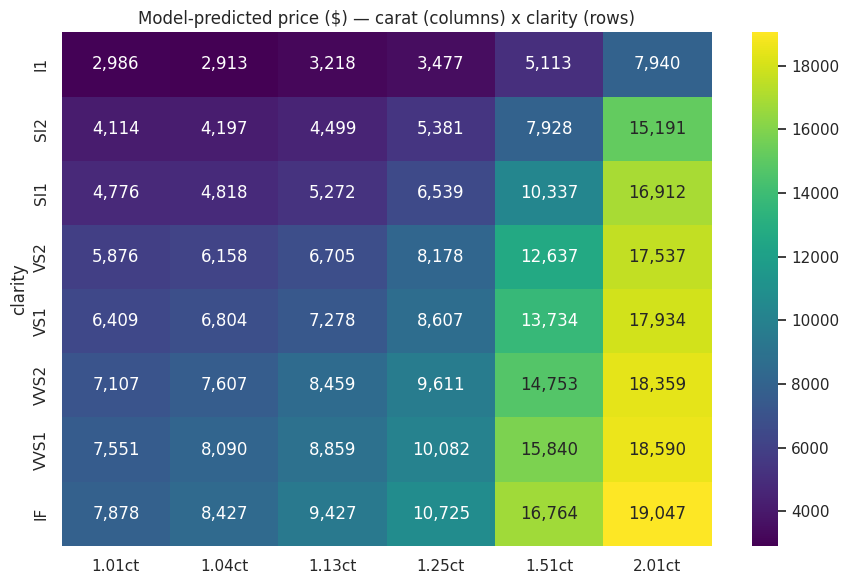

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="viridis", ax=ax)
ax.set_title("Model-predicted price ($) — carat (columns) x clarity (rows)")
plt.tight_layout()
plt.show()

In [22]:
# quantify the interaction: the $ gap between the best (IF) and worst (I1) clarity, at each carat level
clarity_gap = pivot.loc["IF"] - pivot.loc["I1"]
clarity_gap_pct = (pivot.loc["IF"] / pivot.loc["I1"] - 1) * 100
pd.DataFrame({"IF-I1 gap ($)": clarity_gap, "IF-I1 gap (%)": clarity_gap_pct})

,IF-I1 gap ($),IF-I1 gap (%)
1.01ct,4891.339131,163.787002
1.04ct,5514.391367,189.306566
1.13ct,6209.143723,192.962312
1.25ct,7248.504618,208.472561
1.51ct,11650.785399,227.867476
2.01ct,11107.544381,139.902102


### Interpretation

The IF-vs-I1 clarity gap **grows substantially with carat**, both in dollars and in percentage terms, through
the practically-important 1-1.5ct range:

| carat | \$ gap (IF - I1) | % gap |
|---|---|---|
| 1.01ct | \$4,891 | 164% |
| 1.04ct | \$5,514 | 189% |
| 1.13ct | \$6,209 | 193% |
| 1.25ct | \$7,249 | 208% |
| 1.51ct | \$11,651 | 228% |
| 2.01ct | \$11,108 | 140% |

This is a **direct, quantitative contradiction of the heuristic baseline's independence assumption**: a purely
multiplicative model with independent clarity/carat factors would predict a *constant* percentage gap across
carat levels (since both the base rate and the multiplier scale together) — instead the percentage gap climbs
from 164% to 228% between 1.0 and 1.5 carat. **Clarity matters proportionally *more*, not just more in dollar
terms, as stones get larger** — consistent with the strong `volume`/`carat` × `clarity` SHAP interactions found
above.

The drop at 2.01ct (140%, down from 228% at 1.51ct) is most likely a **data sparsity artifact** rather than a
real reversal: very large, very low-clarity (I1) stones are rare in this dataset (the EDA and `4-feat_eng`
notebooks both flagged rare grade-combination cells), so the model's extrapolation in that corner of the feature
space is less reliable — the case study below (the most under-predicted diamond in the test set) is exactly
such a large, low-clarity outlier.

**Practical takeaway**: clarity certification matters most — and should be scrutinized most carefully by a
buyer — for diamonds above roughly 1.2-1.5 carats, where a clarity downgrade costs disproportionately more than
the same downgrade would on a smaller stone.

## 🔎 Local Explanations — Case Studies

Global importance says what matters *on average*; these case studies show **why the model made a specific
prediction** for specific diamonds, decomposed multiplicatively (`exp(shap_i)` ≈ "this feature multiplied the
baseline price by X%"), directly comparable to how the heuristic model in `01-gmg-base_model` is built.

In [ ]:
def explain_diamond(row_position: int, label: str) -> None:
    """Print a multiplicative SHAP decomposition for one test-set diamond and draw its waterfall plot."""
    row_features = x_test.iloc[[row_position]]
    row_transformed = X_test_transformed.iloc[[row_position]]
    row_shap = explainer(row_transformed)

    predicted = model.predict(row_features)[0]
    actual = y_test.iloc[row_position]

    print(f"=== {label} ===")
    print(row_features.to_string(index=False))
    print(f"Actual price:    ${actual:,.2f}")
    print(f"Predicted price: ${predicted:,.2f}")
    print(f"Baseline (exp(base_value)): ${np.exp(row_shap.base_values[0]):,.2f}")
    print()
    contributions = pd.Series(row_shap.values[0], index=feature_names_out).sort_values(
        key=np.abs, ascending=False
    )
    for feat, val in contributions.items():
        print(f"  {feat:24s} shap={val:+.4f}  -> multiplies price by {np.exp(val):.3f}x")
    print()

    shap.plots.waterfall(row_shap[0], show=False)
    plt.title(label)
    plt.tight_layout()
    plt.show()

In [24]:
residuals = y_test.to_numpy() - model.predict(x_test)
test_reset = x_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

median_carat_idx = (test_reset["carat"] - test_reset["carat"].median()).abs().idxmin()
most_expensive_idx = y_test_reset.idxmax()
most_underpredicted_idx = np.argmax(residuals)  # actual >> predicted
most_overpredicted_idx = np.argmin(residuals)  # predicted >> actual

case_studies = {
    "Typical (median-carat) diamond": median_carat_idx,
    "Most expensive diamond in the test set": most_expensive_idx,
    "Most under-predicted diamond (biggest positive residual)": most_underpredicted_idx,
    "Most over-predicted diamond (biggest negative residual)": most_overpredicted_idx,
}
case_studies

{'Typical (median-carat) diamond': 1,
 'Most expensive diamond in the test set': 1185,
 'Most under-predicted diamond (biggest positive residual)': np.int64(1568),
 'Most over-predicted diamond (biggest negative residual)': np.int64(1915)}

=== Typical (median-carat) diamond ===
 carat     depth  table    x    y    z   cut color clarity
   1.2 61.400002   55.0 6.78 6.87 4.19 Ideal     D     VS2
Actual price:    $9,424.00
Predicted price: $9,663.30
Baseline (exp(base_value)): $7,300.63

  cat_ordinal__color       shap=+0.2044  -> multiplies price by 1.227x
  cat_ordinal__clarity     shap=+0.1216  -> multiplies price by 1.129x
  volume__volume           shap=-0.0674  -> multiplies price by 0.935x
  cat_ordinal__cut         shap=+0.0370  -> multiplies price by 1.038x
  num__carat               shap=-0.0299  -> multiplies price by 0.971x
  num__depth               shap=+0.0140  -> multiplies price by 1.014x
  num__table               shap=+0.0007  -> multiplies price by 1.001x



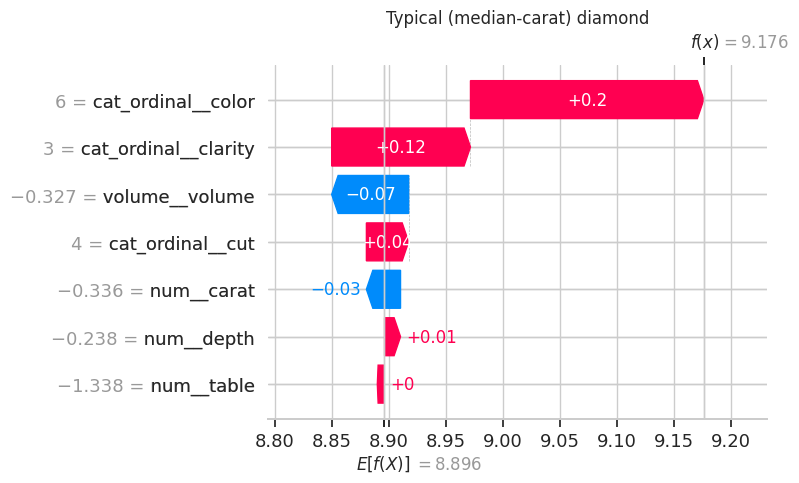

=== Most expensive diamond in the test set ===
 carat     depth  table    x    y    z   cut color clarity
  2.06 62.200001   55.0 8.15 8.19 5.08 Ideal     I     VS2
Actual price:    $18,779.00
Predicted price: $16,158.72
Baseline (exp(base_value)): $7,300.63

  volume__volume           shap=+0.5385  -> multiplies price by 1.713x
  num__carat               shap=+0.2361  -> multiplies price by 1.266x
  cat_ordinal__color       shap=-0.1047  -> multiplies price by 0.901x
  cat_ordinal__clarity     shap=+0.0924  -> multiplies price by 1.097x
  cat_ordinal__cut         shap=+0.0198  -> multiplies price by 1.020x
  num__depth               shap=+0.0075  -> multiplies price by 1.008x
  num__table               shap=+0.0049  -> multiplies price by 1.005x



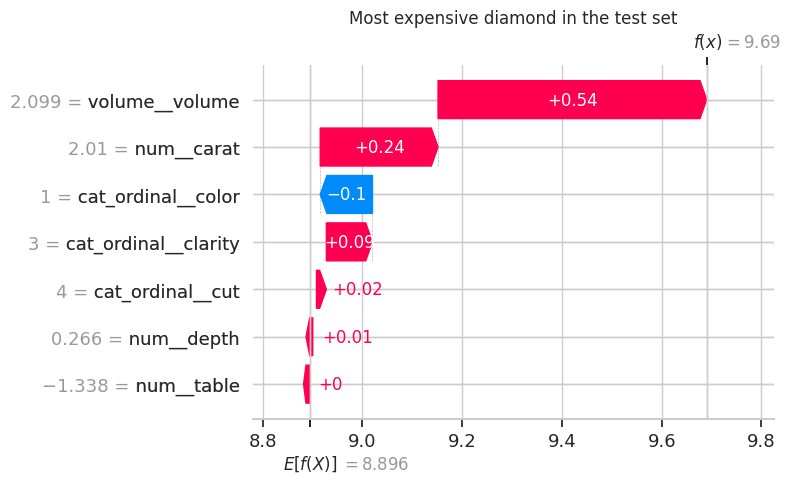

=== Most under-predicted diamond (biggest positive residual) ===
 carat     depth  table    x    y    z  cut color clarity
   3.4 66.800003   52.0 9.42 9.34 6.27 Fair     D      I1
Actual price:    $15,964.00
Predicted price: $9,827.22
Baseline (exp(base_value)): $7,300.63

  volume__volume           shap=+0.6344  -> multiplies price by 1.886x
  cat_ordinal__clarity     shap=-0.5107  -> multiplies price by 0.600x
  num__carat               shap=+0.3070  -> multiplies price by 1.359x
  cat_ordinal__cut         shap=-0.0794  -> multiplies price by 0.924x
  cat_ordinal__color       shap=+0.0759  -> multiplies price by 1.079x
  num__table               shap=-0.0687  -> multiplies price by 0.934x
  num__depth               shap=-0.0614  -> multiplies price by 0.940x



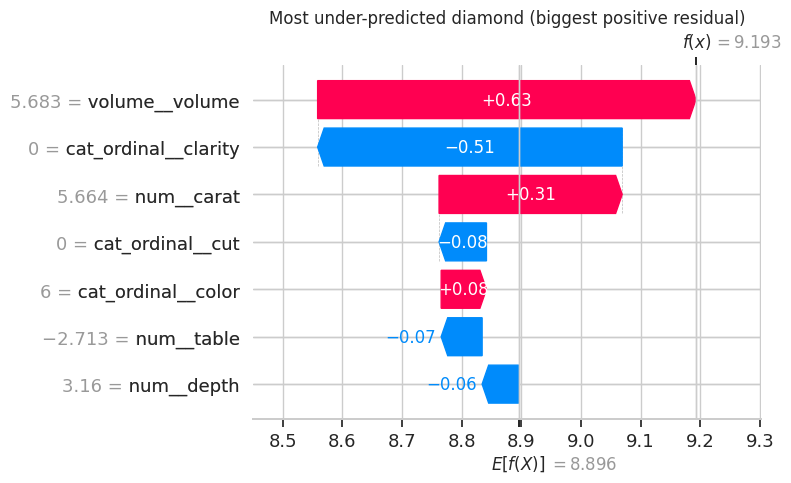

=== Most over-predicted diamond (biggest negative residual) ===
 carat     depth  table   x    y    z   cut color clarity
  1.65 62.200001   55.0 7.6 7.57 4.72 Ideal     G     VS2
Actual price:    $9,425.00
Predicted price: $15,125.36
Baseline (exp(base_value)): $7,300.63

  volume__volume           shap=+0.3283  -> multiplies price by 1.389x
  num__carat               shap=+0.1402  -> multiplies price by 1.151x
  cat_ordinal__clarity     shap=+0.1301  -> multiplies price by 1.139x
  cat_ordinal__color       shap=+0.0876  -> multiplies price by 1.092x
  cat_ordinal__cut         shap=+0.0313  -> multiplies price by 1.032x
  num__depth               shap=+0.0070  -> multiplies price by 1.007x
  num__table               shap=+0.0038  -> multiplies price by 1.004x



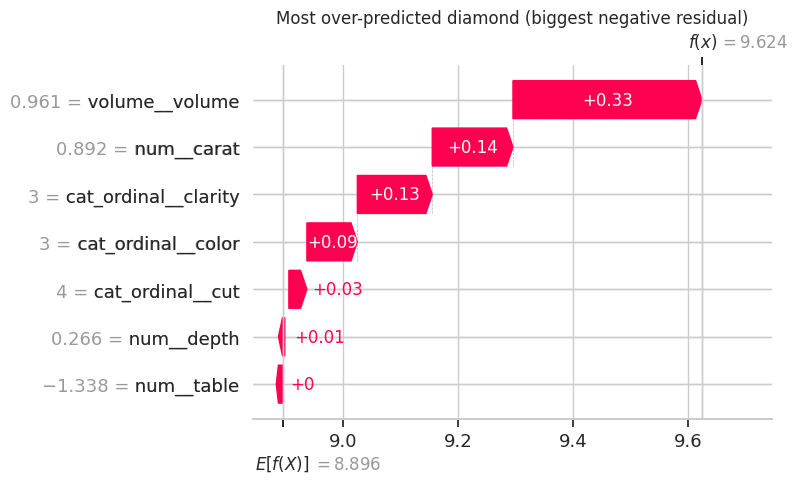

In [25]:
for label, idx in case_studies.items():
    explain_diamond(idx, label)

### Interpretation

- **Typical diamond** (1.20ct, D, VS2, Ideal): predicted \$9,663 vs. actual \$9,424 (≈2.5% high) — a small,
  unremarkable miss. `color` (+1.227x) and `clarity` (+1.129x) are the two features pushing the price up the
  most; interestingly `volume` is *slightly negative* (0.935x) — this diamond's measured `x`/`y`/`z` imply a
  volume marginally smaller than typical for its carat weight (a subtly non-ideal cut), which the model
  correctly picks up on as a small negative.
- **Most expensive diamond in the test set** (2.06ct, I, VS2, Ideal): predicted \$16,159 vs. actual \$18,779
  (≈14% **under**-predicted). `volume` (+1.713x) and `carat` (+1.266x) both fire very strongly — the two
  redundant size signals reinforce each other for this unusually large stone — but the model still falls short
  of the true price. This is consistent with the PDP/SHAP "plateauing at high carat/volume" finding above: the
  model has learned a saturating size effect, but the tiny number of comparably huge stones in training means
  it under-estimates just how much the market actually pays at the extreme high end.
- **Most under-predicted diamond** (3.40ct, Fair, D, I1): predicted \$9,827 vs. actual \$15,964 (≈39% under —
  the single worst miss in the test set). This is the **largest diamond by carat in the entire test set**,
  combined with the *worst* clarity grade (I1) and *worst* cut grade (Fair) — `volume` (+1.886x) and `carat`
  (+1.359x) push hard upward, but `clarity` (0.600x) and `cut` (0.924x) pull hard back down, and the model's
  learned "I1 penalty" — mostly estimated from small-to-mid-size I1 stones, since huge I1 stones are rare — is
  evidently too harsh for a stone this large. This is precisely the segment (extreme carat × poor clarity, a
  rare combination) flagged as a weak spot by the 2D grid analysis above.
- **Most over-predicted diamond** (1.65ct, Ideal, G, VS2): predicted \$15,125 vs. actual \$9,425 (≈60% **over**
  — the single worst miss in the other direction). Every single feature contributes positively to the
  prediction (`volume` +1.389x, `carat` +1.151x, `clarity` +1.139x, `color` +1.092x, `cut` +1.032x) — on paper
  this looks like an entirely unremarkable, solidly good diamond, yet its actual sale price is far below what
  every one of its attributes would suggest. Unlike the other three case studies, there is no single feature or
  segment that explains this miss; it looks like either a genuine pricing anomaly in the source data (a
  particularly good deal, or a data-entry issue not caught by the `4-feat_eng` cleaning, which focused on
  physical-measurement inconsistencies rather than price itself) or an idiosyncratic real-world factor (e.g. a
  quick/distressed sale) that no feature in this dataset could ever capture.

### A deliberate comparison: "small & flawless" vs. "large & flawed"

Two diamonds engineered to have opposite carat/clarity trade-offs, to see how the model weighs size against
quality in a head-to-head case (rather than looking at two random test-set rows).

In [26]:
# NOTE: the training data's carat floor is 1.00 (data/04_feature/diamantes_clean.parquet has carat in
# [1.00, 5.01] - see notebooks/2-exploration). A synthetic 0.5ct example is pure extrapolation outside the
# training distribution; it is included below deliberately, as a cautionary example, alongside two in-range
# comparisons.
small_flawless_in_range = pd.DataFrame(
    [
        {
            "carat": 1.0,
            "depth": 61.5,
            "table": 57.0,
            "x": 6.40,
            "y": 6.43,
            "z": 3.95,
            "cut": "Ideal",
            "color": "D",
            "clarity": "IF",
        }
    ]
)
large_flawed = pd.DataFrame(
    [
        {
            "carat": 2.0,
            "depth": 61.5,
            "table": 57.0,
            "x": 8.06,
            "y": 8.10,
            "z": 4.98,
            "cut": "Fair",
            "color": "J",
            "clarity": "I1",
        }
    ]
)
small_flawless_out_of_range = pd.DataFrame(
    [
        {
            "carat": 0.5,
            "depth": 61.5,
            "table": 57.0,
            "x": 5.15,
            "y": 5.18,
            "z": 3.18,
            "cut": "Ideal",
            "color": "D",
            "clarity": "IF",
        }
    ]
)

for label, sample in [
    ("Small (in-range, 1.0ct) & flawless (D, IF, Ideal)", small_flawless_in_range),
    ("Large & flawed (2.0ct, J, I1, Fair)", large_flawed),
    (
        "Small (OUT-OF-RANGE, 0.5ct - extrapolation!) & flawless (D, IF, Ideal)",
        small_flawless_out_of_range,
    ),
]:
    pred = model.predict(sample)[0]
    print(f"{label}: predicted ${pred:,.2f}")

Small (in-range, 1.0ct) & flawless (D, IF, Ideal): predicted $14,701.39
Large & flawed (2.0ct, J, I1, Fair): predicted $6,437.46
Small (OUT-OF-RANGE, 0.5ct - extrapolation!) & flawless (D, IF, Ideal): predicted $14,248.07


### Interpretation

- **In-range comparison**: a 1.0-carat flawless diamond (D, IF, Ideal) is predicted at **\$14,701** — more than
  **2.3x** the price of a 2.0-carat flawed diamond (J, I1, Fair) at **\$6,437**, despite having *half* the
  carat weight. This is a clean, intuitive, business-relevant confirmation that **quality can dominate size** in
  this model's pricing — directly consistent with permutation importance ranking `clarity` above `carat`.
- **Extrapolation warning**: the out-of-range 0.5-carat flawless diamond is predicted at **\$14,248** — almost
  *identical* to the in-range 1.0-carat flawless prediction (\$14,701), despite being half the size. Since the
  training data's carat floor is exactly **1.00** (`data/04_feature/diamantes_clean.parquet`, confirmed in
  `2-exploration`), the model has **never seen a diamond below 1 carat** — this near-flat prediction is not a
  real "size barely matters below 1ct" finding, it is almost certainly a **boundary/extrapolation artifact**
  (tree-based models like `HistGradientBoostingRegressor` cannot extrapolate a trend beyond the range of leaf
  splits learned from training data; they tend to just repeat the prediction from the nearest training leaf).
  **This model should never be used to price diamonds under 1 carat without retraining on data that actually
  includes that range.**

## 🧭 Error / Segment Analysis

Global metrics hide where the model actually struggles. Breaking residuals down by carat bin and by each
quality grade shows whether error is evenly spread or concentrated in specific segments.

In [27]:
error_df = x_test.copy()
error_df["actual"] = y_test.to_numpy()
error_df["predicted"] = model.predict(x_test)
error_df["abs_pct_error"] = (
    (error_df["predicted"] - error_df["actual"]).abs() / error_df["actual"] * 100
)
error_df["carat_bin"] = pd.cut(
    error_df["carat"], bins=[0, 0.5, 1.0, 1.5, 2.0, 2.5, error_df["carat"].max() + 0.01]
)

carat_bin_mape = error_df.groupby("carat_bin", observed=True)["abs_pct_error"].agg(
    ["mean", "count"]
)
carat_bin_mape

,mean,count
carat_bin,,
"(0.5, 1.0]",6.273977,315
"(1.0, 1.5]",6.325915,2390
"(1.5, 2.0]",7.581606,708
"(2.0, 2.5]",8.811228,362
"(2.5, 3.52]",14.372672,21


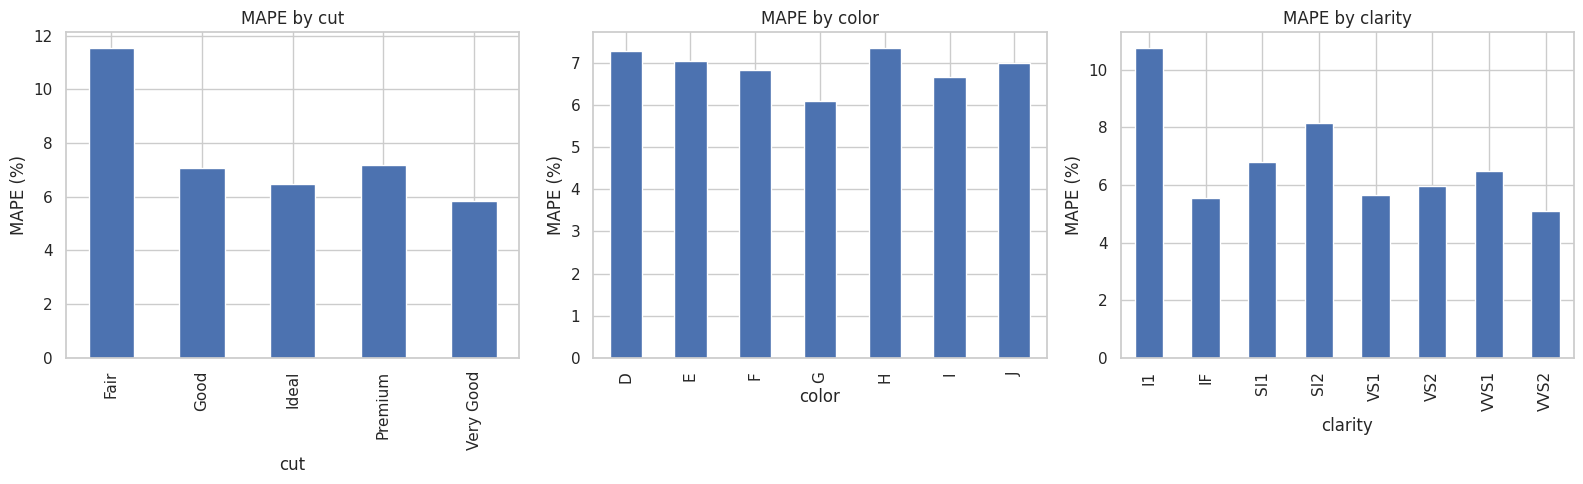

In [ ]:
grade_mape = {}
for grade_col in ["cut", "color", "clarity"]:
    grade_mape[grade_col] = error_df.groupby(grade_col, observed=True)["abs_pct_error"].agg(
        ["mean", "count"]
    )

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, grade_col in zip(axes, ["cut", "color", "clarity"], strict=True):
    grade_mape[grade_col]["mean"].plot(kind="bar", ax=ax)
    ax.set_title(f"MAPE by {grade_col}")
    ax.set_ylabel("MAPE (%)")
plt.tight_layout()
plt.show()

In [29]:
for grade_col in ["cut", "color", "clarity"]:
    print(f"--- {grade_col} ---")
    print(grade_mape[grade_col])
    print()

--- cut ---
                mean  count
cut                        
Fair       11.542434    161
Good        7.072674    379
Ideal       6.479457   1171
Premium     7.168485   1232
Very Good   5.857696    853

--- color ---
           mean  count
color                 
D      7.281090    321
E      7.034280    460
F      6.836161    598
G      6.099531    786
H      7.353512    761
I      6.658957    534
J      6.986153    336

--- clarity ---
              mean  count
clarity                  
I1       10.752781    104
IF        5.535870     51
SI1       6.799727   1006
SI2       8.153253   1054
VS1       5.635037    478
VS2       5.949937    802
VVS1      6.476044     87
VVS2      5.098237    214



### Interpretation

Three genuinely weak segments emerge, and they compound in the worst-case examples above:

- **Carat**: error climbs steadily with size — ≈6.3% MAPE for 1.0-1.5ct (2,390 of the 3,796 test rows, the bulk
  of the data) up to **14.4% MAPE for the >2.5ct tail** (just 21 rows). This mirrors the Deepchecks
  "Train Test Performance" RMSE-degradation finding from `05-...deepcheck-ML-process.ipynb` and the PDP
  plateauing/ICE fan-out seen above — the model is least reliable exactly where training data is thinnest.
- **Cut**: `Fair`-cut diamonds have by far the worst error (**11.54% MAPE**, n=161) — nearly double every other
  cut grade (5.86-7.17%). This directly connects back to `4-feat_eng`'s finding that Fair-cut stones are the
  segment with by far the most depth-proportion outliers (98% of the flagged depth outliers were Fair-cut) —
  Fair cut is inherently the most *physically heterogeneous* grade (irregular proportions with no consistent
  "shape"), which makes it intrinsically harder to price from `depth`/`table`/dimensions alone, independent of
  how much training data it has.
- **Clarity**: the two *worst* clarity grades have the worst error — **I1 (10.75% MAPE, n=104)** and **SI2
  (8.15%, n=1054)** — while the *best* grades (VVS2, VS1, IF) all sit at 5.1-5.6%. This is consistent with `I1`
  ("included") being a catch-all grade for visibly flawed stones whose inclusions vary enormously in type,
  size, and location — all compressed into one label the model can't further distinguish.
- **Color** shows no comparable weak segment — error is fairly flat (6.1-7.4%) across all 7 grades.

**The worst individual misses in the case studies above are exactly where these weak segments intersect**: the
biggest under-prediction was a large + Fair-cut + I1-clarity diamond — three weak segments compounding at once.

## 🧩 Does the Model Agree with Domain Knowledge?

A direct, point-by-point comparison between what this notebook found in the trained model and what the earlier
notebooks found in the raw data / heuristic model.

| EDA / heuristic conclusion (`3-analysis`, `4-feat_eng`, `5-models/01`) | What this notebook found in the trained model |
|---|---|
| `carat` has the strongest raw correlation with `price` (r ≈ 0.79) | **Confirmed, with a nuance**: size (carat + volume combined) is still the dominant driver, but it's *split* across 4 redundant raw columns (`carat`, `x`, `y`, `z`), which dilutes each one's individual permutation importance below `clarity`'s. On the de-duplicated, engineered feature set, `volume` alone is the single most important feature (SHAP). |
| `carat`/`x`/`y`/`z` are severely multicollinear (r = 0.84-0.98) → collapse into `volume` | **Vindicated**: the engineered `volume` feature captures essentially all of that shared signal in one feature, exactly as intended. |
| Stratification strength ranking: `clarity > cut > color` | **Partially confirmed, partially refined**: `clarity` is confirmed as the strongest grade. But once the model properly accounts for carat/size, `color`'s independent contribution (permutation importance 0.114, SHAP 0.109) is far larger than `cut`'s (0.011 / 0.024) — the reverse of `cut > color` implied by the EDA's raw stratification order. Controlling for size changes the picture. |
| `depth`/`table` have negligible price correlation (r ≈ -0.07 / -0.03) | **Confirmed for a linear relationship, but revealed as incomplete**: both have a genuine, non-linear "sweet spot" effect (an inverted-V around the average depth/table value) that a Pearson correlation is structurally blind to, since a symmetric non-monotonic effect averages out to ≈0 correlation. This is new knowledge the EDA could not have surfaced. |
| Heuristic model assumes `clarity`/`color`/`cut` act as **independent** multiplicative factors | **Contradicted for `color` × `clarity`** (the strongest pairwise SHAP interaction in the whole model) and **for `clarity` × carat/volume** (the IF-vs-I1 price gap grows from 164% to 228% between 1.0 and 1.5 carat). **Roughly upheld for `cut`**, which barely interacts with anything. |
| EDA found `cut`/`color`/`clarity` "largely non-redundant" with each other | Consistent for `cut` (weak interactions everywhere), but `color`/`clarity` show a real, non-trivial interaction — "non-redundant" (not collinear) is not the same as "independent in their effect on price", and this notebook shows the latter fails even where the former holds. |
| `4-feat_eng` kept the Fair-cut depth outliers deliberately (98% of flagged rows were Fair-cut) | **The cost of that decision is now visible**: Fair-cut is the model's single worst-performing segment (11.54% MAPE). This doesn't mean the `4-feat_eng` decision was wrong — dropping those rows would only have removed *training examples*, not the underlying physical heterogeneity that makes Fair-cut stones hard to price — but it quantifies the price paid for keeping a difficult, information-bearing segment in the data. |
| `4-feat_eng`'s "carat ≥ 1.00 scope" caveat | **Directly confirmed as a real risk**: a synthetic 0.5-carat query returns an implausible, boundary-artifact prediction, since the model has never seen carat < 1.00 during training. |

## 📊 Analysis of Results and Conclusions

This interpretation exercise did more than rank feature importances — it extracted several pieces of concrete,
checkable knowledge about how the model (and, by extension, the diamond market it was trained on) actually
prices stones:

1. **Size and quality both matter, but quality edges out size once redundancy is accounted for.** `clarity` is
   the single most important raw input by every metric tested (MAPE, R², MAE), ahead of `carat` — not because
   size doesn't matter, but because size's signal is spread across four correlated columns while quality's is
   concentrated in one.
2. **The `volume` feature engineering decision from `4-feat_eng` is vindicated**: it is the single most
   important engineered feature (SHAP), successfully consolidating the `carat`/`x`/`y`/`z` multicollinearity
   into one clean signal.
3. **The heuristic model's independence assumption doesn't fully hold** — `color` and `clarity` interact with
   each other more strongly than either interacts with size, and `clarity`'s dollar/percentage effect grows
   substantially with carat (164% → 228% IF-vs-I1 gap between 1.0 and 1.5ct). `cut`, by contrast, behaves close
   to independently, as the heuristic assumed.
4. **`depth` and `table` have real, non-linear "sweet spot" effects invisible to linear correlation** — both
   EDA-invisible (r ≈ 0) findings only surfaced through SHAP dependence / PDP analysis, and both make physical
   sense (proportions too shallow or too deep both hurt a cut's light performance).
5. **A genuine, if modest, anomaly**: `cut = Premium` is priced slightly *below* `cut = Very Good` in this
   model, confirmed independently by two different interpretation methods (SHAP dependence on transformed
   codes, and a corrected reading of the categorical PDP) — worth a closer look with domain expertise or more
   data before dismissing as noise.
6. **Three weak segments** — large stones (>2.5ct), `Fair` cut, and `I1`/`SI2` clarity — each carry meaningfully
   higher error than the rest of the data, and they compound when they co-occur, as seen in the single worst
   mispredicted diamond in the test set.
7. **A real extrapolation risk**: the model produces a confident-looking but almost certainly unreliable
   prediction for diamonds below 1.00 carat, since none exist in the training data.

## 🧑‍🔬 Recommendations

1. **Treat `clarity`, `color`, and `carat`/`volume` as the three inputs that matter most** for any downstream
   product (e.g. the planned Streamlit app in `7-deploy`) — a simplified or fast-path UI could reasonably
   de-emphasize `depth`/`table`/`cut` without losing much accuracy, though `depth`/`table` should still be
   collected since their small non-linear effect is real.
2. **Enforce the training carat range (1.00-5.01) as a hard input-validation bound** in any deployment —
   predictions below 1 carat are extrapolations that this notebook shows can be misleading (near-flat instead of
   continuing the expected downward trend).
3. **Communicate low confidence for the three weak segments** (very large stones, `Fair` cut, `I1`/`SI2`
   clarity) — e.g. a wider predicted price range or an explicit low-confidence flag — rather than presenting a
   single point estimate with the same implied precision everywhere.
4. **Investigate the `Premium` vs. `Very Good` cut anomaly** with either more data or domain expertise before
   trusting it as a real market signal to act on (e.g. in pricing guidance copy) — it is small but consistent
   across two independent methods, so it deserves a closer look rather than being dismissed outright.
5. **Fix the model artifact's picklability** (move `compute_volume`/`volume_feature_names_out` into an
   importable `src/` module) before `7-deploy` — every notebook and script that loads this joblib artifact
   currently has to redefine these two functions verbatim first, which is fragile and easy to silently break.
6. **Revisit the two catastrophic single-diamond misses** (the 60%-over-predicted and 39%-under-predicted case
   studies) as data-quality leads: the under-prediction is explainable (rare large+low-clarity combination), but
   the over-prediction has no clear feature-based explanation and may point to a residual data issue not caught
   by `4-feat_eng`'s physical-measurement-focused outlier checks.

## 💡 Proposals and Ideas

1. **A dedicated price-based outlier/anomaly check**, complementary to `4-feat_eng`'s measurement-based checks
   (which never looked at `price` itself) — e.g. flagging training rows whose price is a large outlier *given*
   their own SHAP-predicted price, to catch cases like the 60%-over-predicted diamond found here.
2. **A confidence/uncertainty output alongside the point prediction** — e.g. `HistGradientBoostingRegressor`'s
   quantile loss variant (already proposed in `02-...model_selection.ipynb`'s Proposals section), calibrated
   specifically to be wider for the three weak segments identified here.
3. **Model the `Premium` vs. `Very Good` cut anomaly explicitly** — e.g. an interaction term or a revised
   ordinal encoding informed by this finding, then re-check whether it closes or persists.
4. **Expand training data at the extremes** — very large stones (>2.5ct) and rare grade combinations (e.g. large
   + low-clarity) are exactly where this notebook found the most error; targeted data collection there would
   likely improve the model more than further hyperparameter tuning on the well-represented middle of the
   distribution.
5. **A companion "explain this prediction" feature for the `7-deploy` Streamlit app**, using the same
   `exp(shap_i)` multiplicative decomposition built here — since the original problem framing (`1-data`)
   explicitly cites reducing seller/buyer information asymmetry as the business goal, showing *why* the app
   priced a diamond a certain way (not just the number) directly serves that goal.

## 📖 References

- EDA notebook: `notebooks/3-analysis/02-jrz-data_description_Manual-pandas-2024_10_24.ipynb`
- Feature engineering notebook: `notebooks/4-feat_eng/01-gmg-basic-feature-engineering-pipeline-2026_08_18.ipynb`
- Baseline heuristic model: `notebooks/5-models/01-gmg-base_model-2026_08_18.ipynb`
- Final model training: `notebooks/5-models/03-gmg-first_model-2026_08_18.ipynb`
- Model validation: `notebooks/5-models/05-gmg-deepcheck-ML-process-2026_08_18.ipynb`
- <https://scikit-learn.org/stable/modules/permutation_importance.html>
- <https://scikit-learn.org/stable/modules/partial_dependence.html>
- SHAP documentation: <https://shap.readthedocs.io/en/latest/>
- Lundberg & Lee (2017), *A Unified Approach to Interpreting Model Predictions* (SHAP)
- Molnar, C. *Interpretable Machine Learning*: <https://christophm.github.io/interpretable-ml-book/>